# Data notebook

Compares psavert, totals_yoy, cpi_yoy, dspic96, cfpb_bpnp_complaints and narrative_count

In [ ]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

plt.style.use(['dark_background'])

solarized_colors = plt.style.library['Solarize_Light2']['axes.prop_cycle']

plt.rcParams.update({
    'figure.facecolor': '#000000',
    'axes.facecolor': '#000000',
    'savefig.facecolor': '#000000',
    
    'text.color': '#ffffff',
    'axes.labelcolor': '#ffffff',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    
    'grid.color': '#444444',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    
    'font.sans-serif': 'DejaVu Sans',
    'figure.dpi': 120,
    
    'axes.prop_cycle': solarized_colors
})

root_dir = Path.cwd().resolve()
while root_dir.parent != root_dir and not (root_dir / 'data').exists():
    root_dir = root_dir.parent

PROCESSED_DATA_PATH = root_dir / 'data' / 'processed' / 'macro_features.csv'
RAW_CFPB_PATH = root_dir / 'data' / 'raw' / 'cfpb_filtered_bnpl_installment.csv'

print(f"Loading harmonized features from: {PROCESSED_DATA_PATH}")


Loading harmonized features from: C:\Users\Aarush\Documents\Purdue\Momentum\Shadow Credit\data\processed\macro_features.csv


## 1. Data Ingestion & Summary Statistics

In [18]:
# Load dataset
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Display overview
print("=== Dataset Overview ===")
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Observations: {len(df)} monthly periods")
df.info()

display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

=== Dataset Overview ===
Date Range: 2021-01-31 to 2026-08-31
Observations: 68 monthly periods
<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  68 non-null     datetime64[us]
 1   psavert               67 non-null     float64       
 2   dspic96               67 non-null     float64       
 3   cpi_yoy               67 non-null     float64       
 4   totalsl_yoy           67 non-null     float64       
 5   cfpb_bnpl_complaints  68 non-null     int64         
 6   cfpb_narrative_count  68 non-null     int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 3.8 KB


,count,mean,std,min,50%,max
date,68,2023-11-15 00:21:10.588235,NaN,2021-01-31 00:00:00,2023-11-15 00:00:00,2026-08-31 00:00:00
psavert,67.0,5.765672,3.706691,2.2,5.1,26.2
dspic96,67.0,17381.001493,765.891561,16062.9,17481.7,20520.0
cpi_yoy,67.0,0.043745,0.020878,0.013738,0.03353,0.089794
totalsl_yoy,67.0,0.039449,0.032643,-0.011498,0.029783,0.101145
cfpb_bnpl_complaints,68.0,989.073529,715.982204,152.0,743.0,2642.0
cfpb_narrative_count,68.0,620.382353,574.391593,0.0,403.0,2226.0


In [19]:
#dw abt this
display(df.tail(10))

,date,psavert,dspic96,cpi_yoy,totalsl_yoy,cfpb_bnpl_complaints,cfpb_narrative_count
58,2025-11-30,3.8,18035.1,0.026964,0.003433,2059,1397
59,2025-12-31,3.6,18018.5,0.026533,0.030642,2078,1115
60,2026-01-31,4.4,18134.6,0.023912,0.029783,1859,745
61,2026-02-28,3.8,18051.9,0.024340,0.030818,1388,313
62,2026-03-31,3.5,18030.5,0.032860,0.021818,1667,609
63,2026-04-30,2.9,17957.1,0.037792,0.022507,1744,678
64,2026-05-31,2.8,18000.1,0.041666,0.020860,1594,164
65,2026-06-30,2.6,18054.9,0.034635,0.024706,1596,18
66,2026-07-31,3.0,18122.5,0.033039,0.025770,1617,0
67,2026-08-31,NaN,NaN,0.033530,NaN,1541,0


## Personal Savings vs. Credit Expansion & Complaint Velocity

da chart you want
compares personal savings w/ monthy complaint velocity

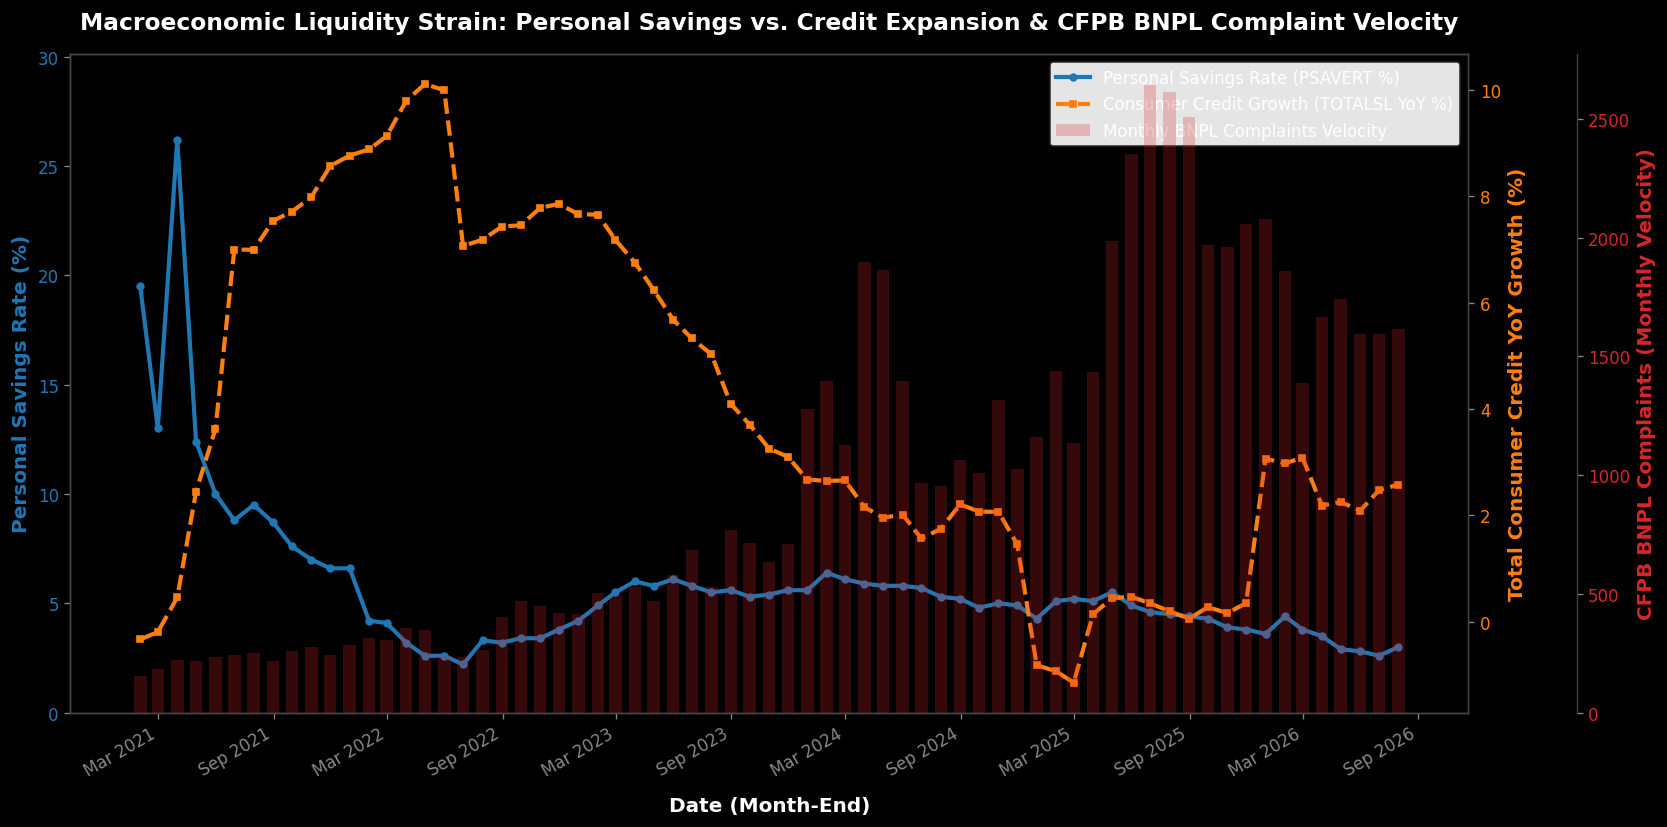

In [20]:
# Clean plotting frame dropping trailing incomplete macro rows
plot_df = df.dropna(subset=['psavert', 'totalsl_yoy', 'cfpb_bnpl_complaints']).copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Personal Savings Rate (%)
color_savings = '#1f77b4'
ax1.set_xlabel('Date (Month-End)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Personal Savings Rate (%)', color=color_savings, fontsize=12, fontweight='bold')
line1 = ax1.plot(plot_df['date'], plot_df['psavert'], color=color_savings, linewidth=2.5, marker='o', markersize=4, label='Personal Savings Rate (PSAVERT %)')
ax1.tick_params(axis='y', labelcolor=color_savings, labelsize=10)
ax1.set_ylim(0, max(plot_df['psavert']) * 1.15)

# Consumer Credit Expansion YoY (%)
ax2 = ax1.twinx()
color_credit = '#ff7f0e'
ax2.set_ylabel('Total Consumer Credit YoY Growth (%)', color=color_credit, fontsize=12, fontweight='bold')
line2 = ax2.plot(plot_df['date'], plot_df['totalsl_yoy'] * 100, color=color_credit, linewidth=2.5, linestyle='--', marker='s', markersize=4, label='Consumer Credit Growth (TOTALSL YoY %)')
ax2.tick_params(axis='y', labelcolor=color_credit, labelsize=10)
ax2.grid(False)  # Avoid overlapping gridlines

#  Complaint Velocity
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 65))
color_complaints = '#d62728'
ax3.set_ylabel('CFPB BNPL Complaints (Monthly Velocity)', color=color_complaints, fontsize=12, fontweight='bold')
bar1 = ax3.bar(plot_df['date'], plot_df['cfpb_bnpl_complaints'], width=20, alpha=0.25, color=color_complaints, label='Monthly BNPL Complaints Velocity')
ax3.tick_params(axis='y', labelcolor=color_complaints, labelsize=10)
ax3.grid(False)

# formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Combined 
lines = line1 + line2 + [bar1]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, framealpha=0.9, facecolor='white', edgecolor="#272222", fontsize=10) # type: ignore

plt.title('Macroeconomic Liquidity Strain: Personal Savings vs. Credit Expansion & CFPB BNPL Complaint Velocity', 
          fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

#more plots :)

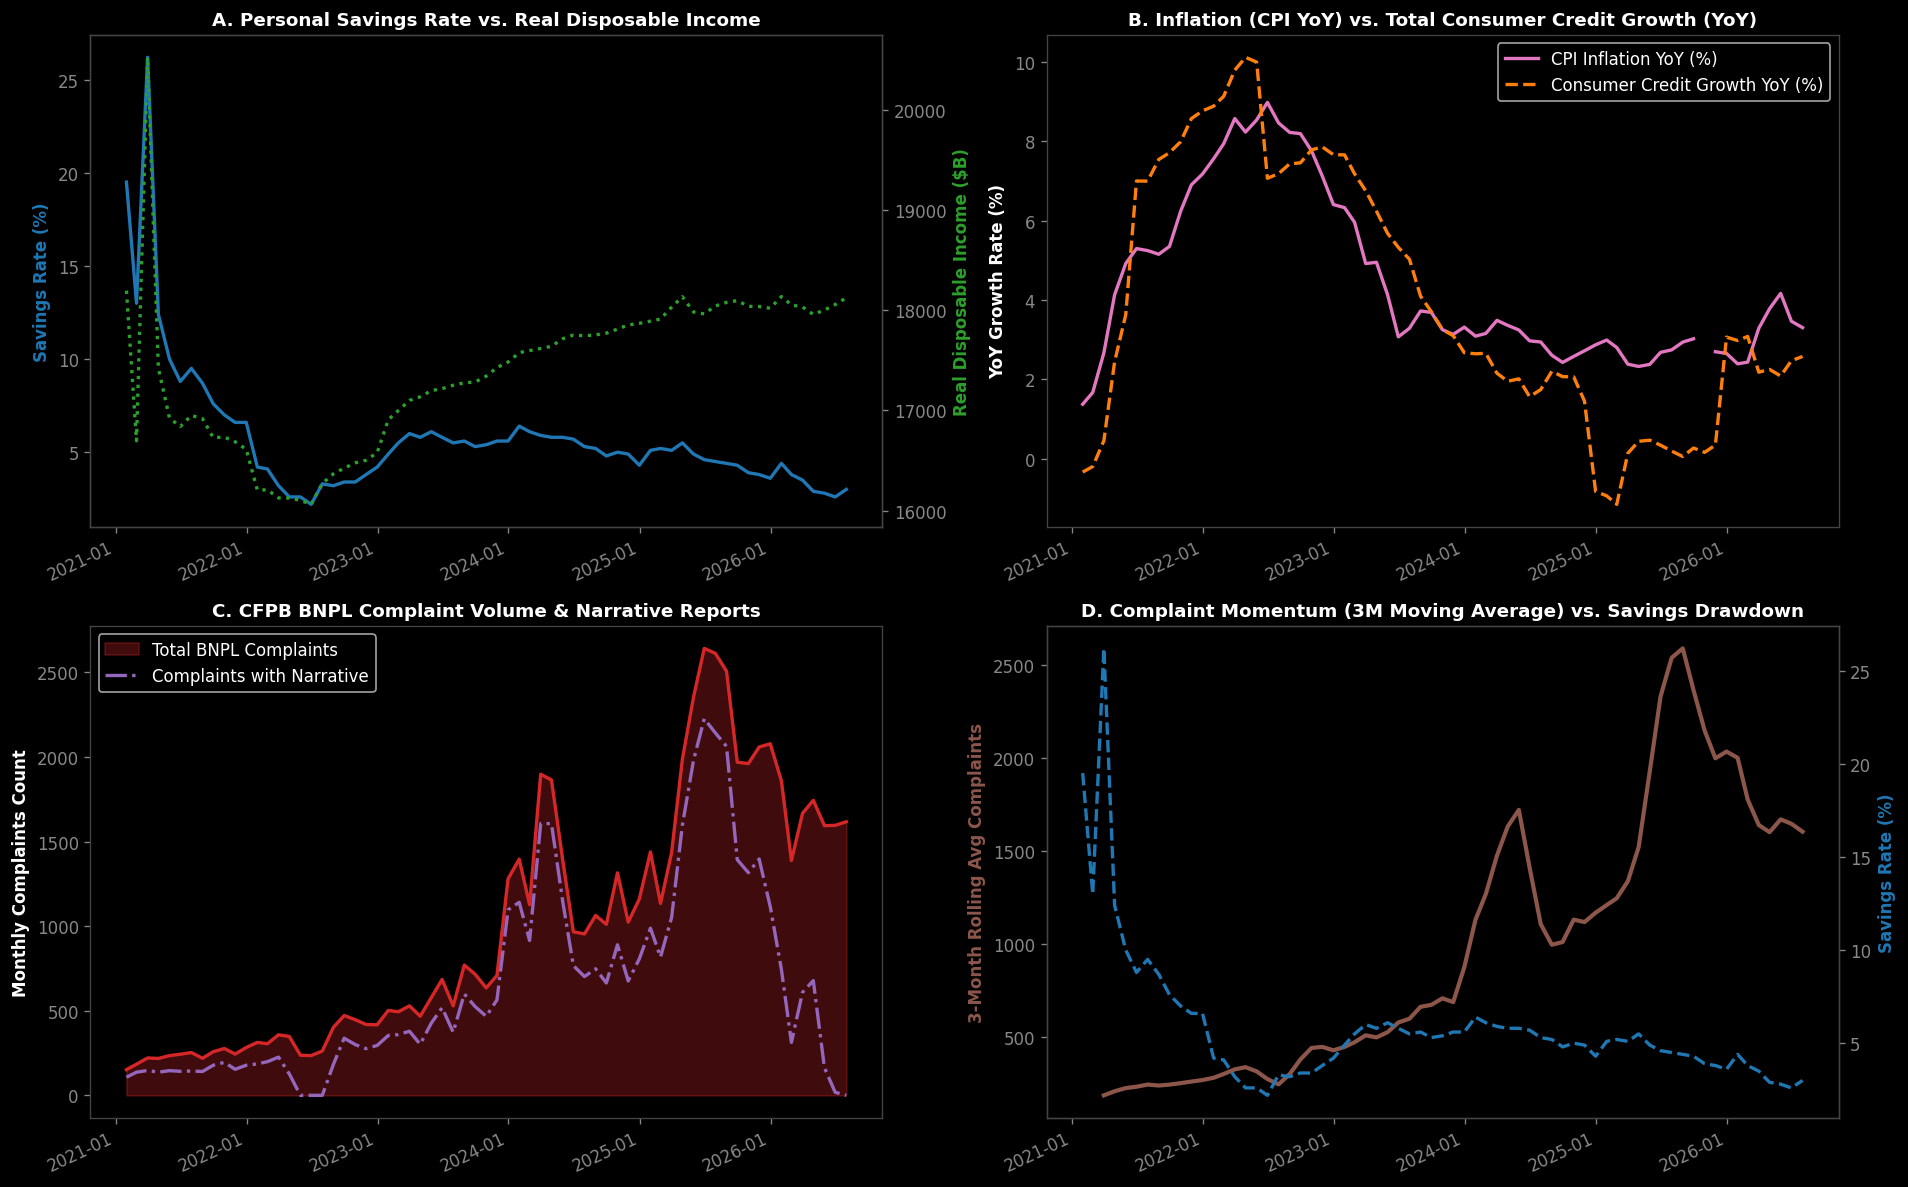

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Savings Rate vs Real Disposable Income
ax = axes[0, 0]
ax.plot(plot_df['date'], plot_df['psavert'], color='#1f77b4', lw=2, label='Personal Savings Rate (%)')
ax.set_ylabel('Savings Rate (%)', color='#1f77b4', fontweight='bold')
ax_r = ax.twinx()
ax_r.plot(plot_df['date'], plot_df['dspic96'], color='#2ca02c', lw=2, linestyle=':', label='Real Disposable Income ($B)')
ax_r.set_ylabel('Real Disposable Income ($B)', color='#2ca02c', fontweight='bold')
ax_r.grid(False)
ax.set_title('A. Personal Savings Rate vs. Real Disposable Income', fontweight='bold', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# CPI Inflation vs Consumer Credit Expansion YoY
ax = axes[0, 1]
ax.plot(plot_df['date'], plot_df['cpi_yoy'] * 100, color='#e377c2', lw=2, label='CPI Inflation YoY (%)')
ax.plot(plot_df['date'], plot_df['totalsl_yoy'] * 100, color='#ff7f0e', lw=2, linestyle='--', label='Consumer Credit Growth YoY (%)')
ax.set_ylabel('YoY Growth Rate (%)', fontweight='bold')
ax.set_title('B. Inflation (CPI YoY) vs. Total Consumer Credit Growth (YoY)', fontweight='bold', fontsize=11)
ax.legend(loc='upper right', frameon=True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Total BNPL Complaints & Narratives Volume
ax = axes[1, 0]
ax.fill_between(plot_df['date'], plot_df['cfpb_bnpl_complaints'], color='#d62728', alpha=0.3, label='Total BNPL Complaints')
ax.plot(plot_df['date'], plot_df['cfpb_bnpl_complaints'], color='#d62728', lw=2)
ax.plot(plot_df['date'], plot_df['cfpb_narrative_count'], color='#9467bd', lw=2, linestyle='-.', label='Complaints with Narrative')
ax.set_ylabel('Monthly Complaints Count', fontweight='bold')
ax.set_title('C. CFPB BNPL Complaint Volume & Narrative Reports', fontweight='bold', fontsize=11)
ax.legend(loc='upper left', frameon=True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 3-Month Rolling Complaint Acceleration vs Savings Rate
ax = axes[1, 1]
rolling_complaints = plot_df['cfpb_bnpl_complaints'].rolling(window=3).mean()
ax.plot(plot_df['date'], rolling_complaints, color='#8c564b', lw=2.5, label='BNPL Complaints (3M MA)')
ax.set_ylabel('3-Month Rolling Avg Complaints', color='#8c564b', fontweight='bold')
ax_s = ax.twinx()
ax_s.plot(plot_df['date'], plot_df['psavert'], color='#1f77b4', lw=2, linestyle='--', label='Personal Savings Rate (%)')
ax_s.set_ylabel('Savings Rate (%)', color='#1f77b4', fontweight='bold')
ax_s.grid(False)
ax.set_title('D. Complaint Momentum (3M Moving Average) vs. Savings Drawdown', fontweight='bold', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

for a in axes.flat:
    plt.setp(a.xaxis.get_majorticklabels(), rotation=25, ha='right')

fig.tight_layout()
plt.show()

This is more used in ml i think but it shows what features correlate so its usefull for finding patterns

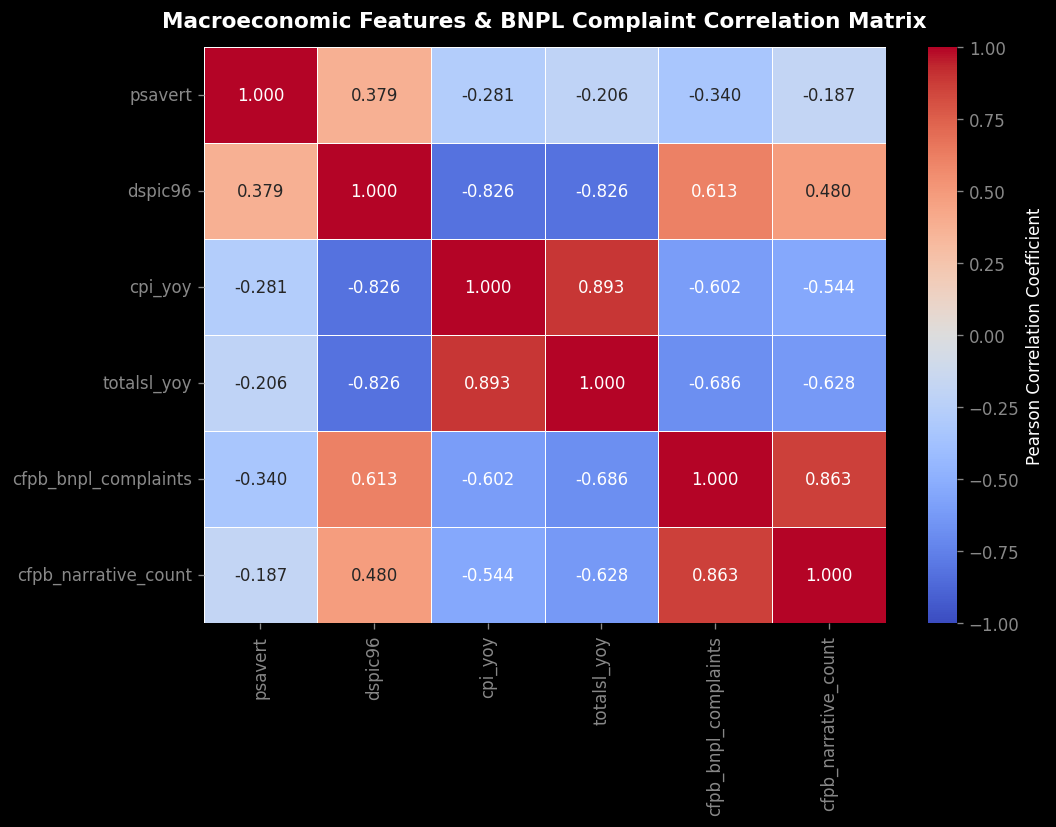

In [22]:
# Correlation Matrix
features_corr = plot_df[['psavert', 'dspic96', 'cpi_yoy', 'totalsl_yoy', 'cfpb_bnpl_complaints', 'cfpb_narrative_count']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(features_corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, 
            cbar_kws={'label': 'Pearson Correlation Coefficient'}, linewidths=0.5)
plt.title('Macroeconomic Features & BNPL Complaint Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

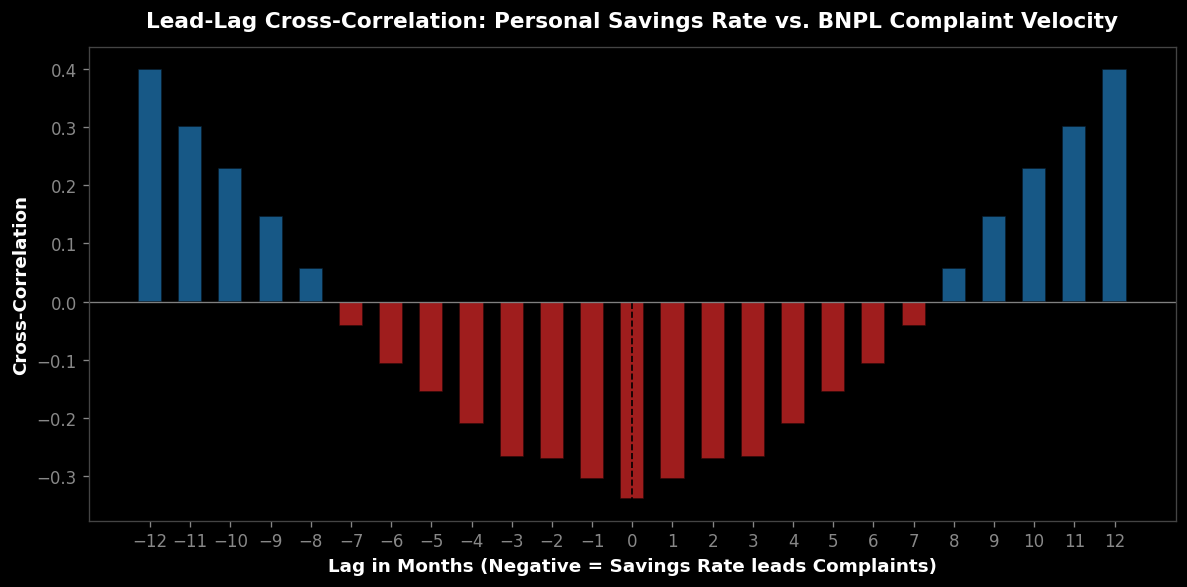

In [23]:
# Wanted to look at correlation in savings rate and complaint velocity
lags = range(-12, 13)
savings_series = plot_df['psavert']
complaint_series = plot_df['cfpb_bnpl_complaints']

cross_corrs = []
for lag in lags:
    if lag < 0:
        # Savings leads complaints by |lag| months
        c = savings_series.iloc[:lag].corr(complaint_series.iloc[-lag:])
    elif lag > 0:
        # Complaints lead savings by lag months
        c = savings_series.iloc[lag:].corr(complaint_series.iloc[:-lag])
    else:
        c = savings_series.corr(complaint_series)
    cross_corrs.append(c)

plt.figure(figsize=(10, 5))
plt.bar(lags, cross_corrs, color=['#d62728' if c < 0 else '#1f77b4' for c in cross_corrs], alpha=0.75, edgecolor='black', width=0.6)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8)
plt.xlabel('Lag in Months (Negative = Savings Rate leads Complaints)', fontsize=11, fontweight='bold')
plt.ylabel('Cross-Correlation', fontsize=11, fontweight='bold')
plt.title('Lead-Lag Cross-Correlation: Personal Savings Rate vs. BNPL Complaint Velocity', fontsize=13, fontweight='bold', pad=12)
plt.xticks(lags)
plt.tight_layout()
plt.show()